In [24]:
# used to check the integrated rate

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import scipy.integrate as integrate

import analysis.utils as utils # here's rate calculation functions
import analysis.plotter as plotter
import analysis.config as config

import math

In [26]:
# just for testing
m_D = 1 # GeV
xs = 10**-1 #pb

E1 = 1*10**-6; E2 = 50 #GeV
c1 = 0.751; c2 = 0.561


In [27]:
# when v_esc. = inf. compare before and after the approximation:

In [28]:
# tru from 1st version of analytical code
def get_rate_15(A = 28, v_0 = 230, E1 = 1*10**-6, E2 = 50, CL = 0.95, 
                      m_D = m_D, xs = xs):
    
    m_T = A*0.938 #[GeV]

    E0 = 1/2 * m_D * (v_0/(3*10**5))**2 # in GeV
    r = 4*m_D*m_T/(m_D+m_T)**2
    R0 = 540/(A*m_D)*(xs)*1*(v_0/230) #[pb]
    k = c2/(E0*r) + (1/3*(6.92*10**-3)**2*A*((1.14*A)**1/3)**2) # k factor in integral, see details in note
    R = c1 * R0/E0/r/k * (np.exp(-k*E1) - np.exp(-k*E2)) *A *A
    print("R0 = " , R0)
    return R

get_rate_15(E1 = 0)

R0 =  1.9285714285714286


2024.0855539146391

In [15]:
def get_rate_14(E_KeV, A = 28, v_0 = 230, m_D = m_D, xs = xs):
    E = E_KeV/1e6   # in GeV
    m_T = A*0.938  #[GeV]

    E0 = 1/2 * m_D * (v_0/(3*10**5))**2 # in GeV
    r = 4*m_D*m_T/(m_D+m_T)**2
    R0 = 540/(A*m_D)*(xs)*1*(v_0/230) #[pb]
    k = c2/(E0*r) + (1/3*(6.92*10**-3)**2*A*((1.14*A)**1/3)**2) # k factor in integral, see details in note
    return c1 * R0/E0/r * np.exp(-k*E) *A*A * 1e-6

get_rate_14(0)

27338.00674727792

In [16]:
# tru from 2st version of numerical code

def get_rate_12(E_KeV, m_D = m_D, xs = xs):
    """
    Calculate the differential rate from numerical method, see derivation in paper"""
    E = E_KeV/1e6 # in GeV
    R_0 = 540./config.A/m_D*xs*1*(config.v_0/230) 
    E_0 = 1/2 * m_D * (config.v_0/(3*10**5))**2 # in GeV
    m_T = config.A*0.938 
    r = 4*(m_D*m_T)/(m_D+m_T)**2
    
    v_min = np.sqrt(E/E_0/r)*config.v_0
    diff1 = R_0/E_0/r*np.pi**(1/2)/4*config.v_0/config.v_E*(math.erf((v_min+config.v_E)/config.v_0)-math.erf((v_min-config.v_E)/config.v_0) )
    F = np.exp(-1/3*(6.92*10**-3)**2*config.A*((1.14*config.A)**1/3)**2)
    if diff1 * F * config.A**2 * 1e-6 < 0:
        print("aaaa negative rate")
    return diff1 * F * config.A**2 * 1e-6
  
get_rate_12(0)

25048.6975969584

In [17]:
# compare the total integrated rate:
print(integrate.quad(get_rate_12, 0, 40)[0])
print(integrate.quad(get_rate_14, 0, 40)[0])
print(get_rate_15(E1 = 0))

1924.37388488559
2024.085553914639
2024.0855539146391


(0.0, 5.0)

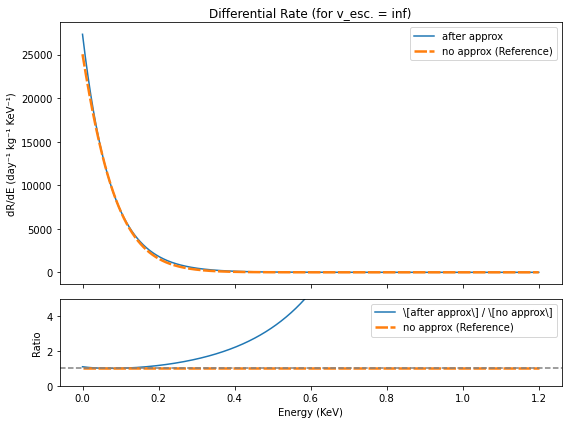

In [18]:
# compare their differential rate plot:
E_Rs_KeV = np.linspace(0.0, 1.2, 1000)
dRs0 = [get_rate_14(E) for E in E_Rs_KeV]
dRs1 = [get_rate_12(E) for E in E_Rs_KeV]
fig, axes = plotter.plot_differential_rate(E_Rs_KeV, [dRs0, dRs1], ref_index = 1, 
                               labels=["after approx","no approx"], panel_type= "ratio")
axes[0].set_title("Differential Rate (for v_esc. = inf)")
axes[1].set_ylim(0, 5)



[25048.6975969584,
 24725.11249193262,
 24403.91527693263,
 24085.146205348945,
 23768.842980072903,
 23455.040834971995,
 23143.7726143291,
 22835.06885028708,
 22528.957838340273,
 22225.465710913235,
 21924.616509066826,
 21626.43225237084,
 21330.933006981882,
 21038.13695196454,
 20748.060443893195,
 20460.71807977134,
 20176.12275830457,
 19894.285739562718,
 19615.216703066242,
 19338.923804331116,
 19065.413729906028,
 18794.691750935053,
 18526.761775278464,
 18261.626398223583,
 17999.286951817227,
 17739.743552850625,
 17482.99514952705,
 17229.03956684208,
 16977.87355070559,
 16729.49281083428,
 16483.892062442803,
 16241.065066761244,
 16001.004670405939,
 15763.702843630352,
 15529.150717482058,
 15297.33861989142,
 15068.256110717104,
 14841.892015773052,
 14618.234459861014,
 14397.270898832403,
 14178.988150702515,
 13963.37242584006,
 13750.409356254178,
 13540.084024000791,
 13332.380988729728,
 13127.284314393593,
 12924.777595138963,
 12724.843980399988,
 12527.46

In [9]:
# Compare with v_esc. = finite formula (Eq. 3.13)

In [10]:
# tru from 2st version of numerical code
def get_rate_13(E_KeV, v_esc = 600, m_D = m_D, xs = xs):
    """
    Calculate the differential rate from numerical method, see derivation in paper"""
    E = E_KeV/1e6 # change to GeV
    R_0 = 540./config.A/m_D*xs*1*(config.v_0/230) 
    E_0 = 1/2 * m_D * (config.v_0/(3*10**5))**2 # in GeV
    m_T = config.A*0.938 
    r = 4*(m_D*m_T)/(m_D+m_T)**2
    
    v_min = np.sqrt(E/E_0/r)*config.v_0
    if v_min > v_esc:
        return 0
    diff1 = R_0/E_0/r*np.pi**(1/2)/4*config.v_0/config.v_E*(math.erf((v_min+config.v_E)/config.v_0)-math.erf((v_min-config.v_E)/config.v_0) )
    x = v_esc/config.v_0
    coef = math.erf(x) - 2/np.pi**0.5 * x * np.exp(-x**2)
    diff2 = 1/coef * (diff1 - R_0/E_0/r*np.exp(-x**2))
    F = np.exp(-1/3*(6.92*10**-3)**2*config.A*((1.14*config.A)**1/3)**2)
    if diff2 < 0:
        print("aaaa negative rate!!")
        return diff2 * F * config.A**2 * 1e-6
        # return 0
    else:
        return diff2 * F * config.A**2 * 1e-6
    
get_rate_13(0)

25097.851598746787

In [13]:
print(integrate.quad(get_rate_12, 0, 40)[0])
get_rate_13(15)

1924.37388488559


0

In [11]:
# check the total rate
print(integrate.quad(lambda E: get_rate_13(E, v_esc=600), 0, 40)[0])
print(integrate.quad(lambda E: get_rate_13(E, v_esc=9999), 0, 40)[0])
print(integrate.quad(get_rate_12, 0, 40)[0])
print(integrate.quad(get_rate_14, 0, 40)[0])
print(get_rate_15(E1 = 0))

1895.8484599081528
1924.37388488559
1924.37388488559
2024.085553914639
2.5817417779523457


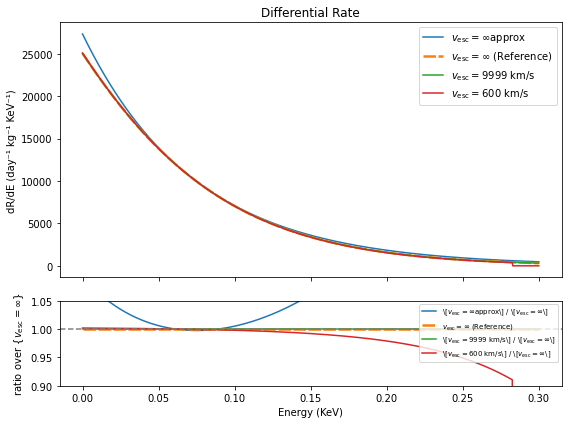

In [12]:
# compare their differential rate plot:
E_Rs_KeV = np.linspace(0.0, 0.3, 1000)
dRs0 = [get_rate_14(E) for E in E_Rs_KeV]
dRs1 = [get_rate_12(E) for E in E_Rs_KeV]
dRs2 = [get_rate_13(E, v_esc=9999) for E in E_Rs_KeV]
dRs3 = [get_rate_13(E, v_esc=600) for E in E_Rs_KeV]

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # default color cycle

labels = [
    r'$v_{\mathrm{esc}}=\infty \mathrm{approx}$', 
    r'$v_{\mathrm{esc}}=\infty$', 
    r'$v_{\mathrm{esc}}=9999$ km/s', 
    r'$v_{\mathrm{esc}}=600$ km/s'
]

fig, axes = plotter.plot_differential_rate(E_Rs_KeV, [dRs0, dRs1, dRs2, dRs3], ref_index = 1, panel_type="ratio",
                               labels=labels)

axes[0].set_title("Differential Rate")
axes[1].set_ylabel("ratio over {"+r'$v_{\mathrm{esc}}=\infty$'+"}" )
axes[1].legend(fontsize=7) 
axes[1].set_ylim(0.90, 1.05)
fig.savefig("rateplot1.png", dpi=600) 

1895.8484599081528
1924.37388488559
1924.37388488559
2024.085553914639


(0.9, 1.5)

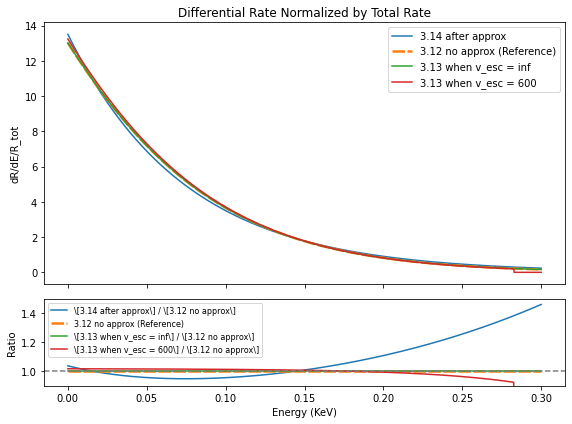

In [13]:
# also try normalization:
print(integrate.quad(lambda E: get_rate_13(E, v_esc=600), 0, 40)[0])
print(integrate.quad(lambda E: get_rate_13(E, v_esc=9999), 0, 40)[0])
print(integrate.quad(get_rate_12, 0, 40)[0])
print(integrate.quad(get_rate_14, 0, 40)[0])

E_Rs_KeV = np.linspace(0.0, 0.3, 1000)
dRs0 = [get_rate_14(E)/integrate.quad(get_rate_14, 0, 40)[0] for E in E_Rs_KeV]
dRs1 = [get_rate_12(E)/integrate.quad(get_rate_12, 0, 40)[0] for E in E_Rs_KeV]
dRs2 = [get_rate_13(E, v_esc=9999)/integrate.quad(lambda E: get_rate_13(E, v_esc=9999), 0, 40)[0] for E in E_Rs_KeV]
dRs3 = [get_rate_13(E, v_esc=600)/integrate.quad(lambda E: get_rate_13(E, v_esc=600), 0, 40)[0] for E in E_Rs_KeV]

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # default color cycle

fig, axes = plotter.plot_differential_rate(E_Rs_KeV, [dRs0, dRs1, dRs2, dRs3], ref_index = 1, panel_type="ratio",
                               labels=["3.14 after approx","3.12 no approx","3.13 when v_esc = inf", "3.13 when v_esc = 600"])

axes[0].set_title("Differential Rate Normalized by Total Rate")
axes[1].legend(fontsize=8) 
axes[0].set_ylabel("dR/dE/R_tot")
axes[1].set_ylim(0.90, 1.5)

In [14]:
# finally the sensitivity curve

from tqdm import tqdm
import os

def get_Nexp_from_CL(CL = 0.95):
    return -np.log(1-CL)

def get_limit_contour(A = 28, v_0 = 230, E1_KeV = 1, E2_KeV = 50, CL = 0.95, 
                    massrange = [-1, 4], xsrange = [-4, 0], DAQday = 1, DAQkg = 1,
                    npoints = 10, rate_type = 15, tag = '', mode = ''):
    """
    Function to calculate the limit contour. 
    
    rate_type: determines which rate function to use:
    - 15 -> get_rate_15 -> the approximated analytical method
    - 12 -> get_rate_12 -> v_esc = inf, no approximation
    - 13 -> get_rate_13 -> use exact formula for v_esc=600
    - 14 -> get_rate_14 -> numerical integral of the approximated analytical method (= R15)

    tag: a string that will be added to the output file name.
    """
    output_filename = f"data/limit_contour_output_rate{rate_type}_{tag}.npz" if tag else "data/limit_contour_output.npz"

    # Check if the output file already exists
    if mode == 'fast':
        if os.path.exists(output_filename):
            data = np.load(output_filename)
            return data["mass"], data["xs"]
    
    contour_mass = []
    contour_xs = []
    lgmasses  = np.linspace(*massrange, npoints)
    lgxses = np.linspace(*xsrange,npoints)
    m_T = A*0.938 #[GeV]

    for i, m_D in enumerate(tqdm(10**lgmasses, total=npoints, desc="Scanning m_D", unit="mass")):
        for j, xs in enumerate(10**lgxses):
            if rate_type == 15:
                R_tot = get_rate_15(A = 28, v_0 = 230, E1 = E1_KeV*1e-6, E2 = E2_KeV*1e-6, 
                      m_D = m_D, xs = xs)
            elif rate_type == 12:
                R_tot = integrate.quad(lambda E: get_rate_12(E, m_D = m_D, xs =xs), E1_KeV, 40)[0]
            elif rate_type == 13:
                R_tot = integrate.quad(lambda E: get_rate_13(E, v_esc = 600, m_D = m_D, xs =xs), E1_KeV, 40)[0]
            elif rate_type == 14:
                R_tot = integrate.quad(lambda E: get_rate_14(E, m_D = m_D, xs =xs), E1_KeV, 40)[0]
            else: 
                raise ValueError(f"Invalid rate_type: {rate_type}. Supported values are 13 and 14.")
            
            # find the points on the contour
            if abs(R_tot*DAQday*DAQkg - get_Nexp_from_CL(CL)) < 0.01:
                # print(R00, R01, R00/R01) # sanity check: the difference is around 10**-7
                contour_mass.append(m_D)
                contour_xs.append(xs)

    # Save the output to a file with the tag in the filename
    np.savez(output_filename, mass=np.array(contour_mass), xs=np.array(contour_xs))

    return np.array(contour_mass), np.array(contour_xs)

In [ ]:
tag = 'test'
get_limit_contour(tag=tag, npoints = 800, rate_type=15, A=28, E1_KeV=0.5, E2_KeV=60, xsrange=[-7, -1], massrange=[0, 1], DAQday=365, CL = 0.90) # 1.64485 sigma
# get_limit_contour(tag=tag, npoints = 300, rate_type=12, A=28, E1_KeV=0.63, E2_KeV=60, xsrange=[-5, -1], massrange=[0, 1], DAQday=11, CL = 0.95) # 1.64485 sigma
# get_limit_contour(tag=tag, npoints = 300, rate_type=13, A=28, E1_KeV=0.63, E2_KeV=60, xsrange=[-5, -1], massrange=[-1, 1], DAQday=11, CL = 0.95) # 1.64485 sigma
print(".")


Scanning m_D: 100%|██████████| 800/800 [00:02<00:00, 329.84mass/s]

.


In [ ]:
# import from my calculation

data12 = np.load(f"data/limit_contour_output_rate{12}_{tag}.npz")
mass12 = data12["mass"]; xs12 = data12["xs"]

data13 = np.load(f"data/limit_contour_output_rate{13}_{tag}.npz")
mass13 = data13["mass"]; xs13 = data13["xs"]

data15 = np.load(f"data/limit_contour_output_rate{15}_{tag}.npz")
mass15 = data15["mass"]; xs15 = data15["xs"]

In [17]:
# import from Claudia's talk
# data_damicM = np.loadtxt("Damic-M 1 kg-y.csv", delimiter=",") 
# data_damic = np.loadtxt("damic at snolab.csv", delimiter=",") 

# there's mistake in digitalizing, 0.1 of the actual correct number
# for now, use this; remember to fix it in the future!!!
# mass_damicM, xs_damicM = data_damicM[:,0], data_damicM[:,1]*1e37
# mass_damic, xs_damic = data_damic[:,0], data_damic[:,1]*1e37

#import radomir's data
data_rad = np.loadtxt("radomir's curve.csv", delimiter=",") 
mass_rad, xs_rad = data_rad[:,0], data_rad[:,1]*1e36


In [18]:
# import damic paper data:
data = np.loadtxt("nominal.csv", delimiter=",") 
upper = np.loadtxt("upper.csv", delimiter=",") 
lower = np.loadtxt("lower.csv", delimiter=",") 

mass2, xs2 = upper[:,0], upper[:,1]*1e36
mass3, xs3 = lower[:,0], lower[:,1]*1e36
mass4, xs4 = data[:,0], data[:,1]*1e36

<Figure size 1008x1440 with 0 Axes>

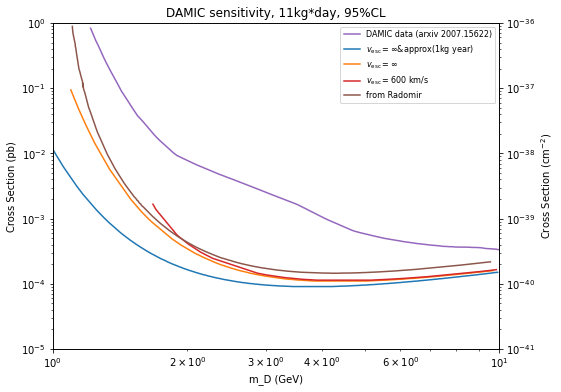

In [37]:
# plot!!!!!
# todo: put the sensitivity curve plotting in another file

plt.figure(figsize=(14, 20))
fig, ax1 = plt.subplots(figsize=(8, 6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']  # default color cycle

# digitalized from paper
# ax1.plot(mass2, xs2, color=colors[4], alpha=0.5)
# ax1.plot(mass3, xs3, label='DAMIC expectation (arxiv 2007.15622)', color=colors[4], alpha=0.5)
ax1.plot(mass4, xs4, label='DAMIC data (arxiv 2007.15622)', color=colors[4], alpha=1)
# common_mass = np.linspace(max(min(mass2), min(mass3)), min(max(mass2), max(mass3)), 500)
# xs2_interp = np.interp(common_mass, mass2, xs2)
# xs3_interp = np.interp(common_mass, mass3, xs3)
# ax1.fill_between(common_mass, xs2_interp, xs3_interp, color=colors[4], alpha=0.5)

# from Claudia's Slides
# ax1.plot(mass_damicM, xs_damicM, label='DAMIC-M 1kg*y (Claudia)', color='lime')
# ax1.plot(mass_damic, xs_damic, label='DAMIC (Claudia)', color='gold')

# from my calculation
ax1.plot(mass15, xs15, label=r'$v_{\mathrm{esc}}=\infty & \mathrm{approx}$'+'(1kg year)', color=colors[0])
ax1.plot(mass12, xs12, label=r'$v_{\mathrm{esc}}=\infty$', color=colors[1])
ax1.plot(mass13, xs13, label=r'$v_{\mathrm{esc}}=600$ km/s', color=colors[3])
ax1.plot(mass_rad, xs_rad, label='from Radomir', color=colors[5])


ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_title('DAMIC sensitivity, 11kg*day, 95%CL')
ax1.set_xlabel('m_D (GeV)')
ax1.set_ylabel('Cross Section (pb)')
ax1.set_xlim(1,10)
ax1.set_ylim(1e-5,1e0)

ax1.axhline(0, color='black', linewidth=0.5, linestyle="--")
ax1.axvline(0, color='black', linewidth=0.5, linestyle="--")

# second axis
ax2 = ax1.twinx()
ax2.set_yscale("log")
ax2.set_ylabel(r'Cross Section (cm$^{-2}$)')
ax2.set_ylim(ax1.get_ylim()[0] * 1e-36, ax1.get_ylim()[1] * 1e-36)

ax1.legend(title='v0 = 230km/s, Emin = 0.4 KeV, CL = 95%, Si A=28, 11kg*day, 95%CL')
ax1.legend(fontsize = 8)
plt.show()

fig.savefig("sensitivity_plot.png", dpi=600) 